# 0. Cài đặt thư viện

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
df = pd.read_csv("/content/drive/MyDrive/projects/women_clothing_reviews/Womens Clothing E-Commerce Reviews_Norm.csv")
df.head(2)

,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Title,Review Text,Title_lemmatized,Review Text_lemmatized,Polarity,Neutral,Negative,Positive,Sentiment
0,1077,60,3,0,0,General,Dresses,Dresses,major design flaws,high hopes dress wanted work initially ordered...,design flaw,hope dress want work initi order petit size fa...,0.6908,0.782,0.0,0.218,Positive
1,1049,50,5,1,0,General Petite,Bottoms,Pants,favorite buy,love love love jumpsuit fun flirty fabulous ti...,favorit buy,love love love jumpsuit fun flirti fabul time ...,0.9638,0.174,0.0,0.826,Positive


In [18]:
df.drop(columns =['Title', 'Review Text', 'Polarity', 'Neutral', 'Negative', 'Positive', 'Sentiment'], inplace=True)
df.head(2)

,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Title_lemmatized,Review Text_lemmatized
0,1077,60,3,0,0,General,Dresses,Dresses,design flaw,hope dress want work initi order petit size fa...
1,1049,50,5,1,0,General Petite,Bottoms,Pants,favorit buy,love love love jumpsuit fun flirti fabul time ...


# 1.Tiền xử lý dữ liệu

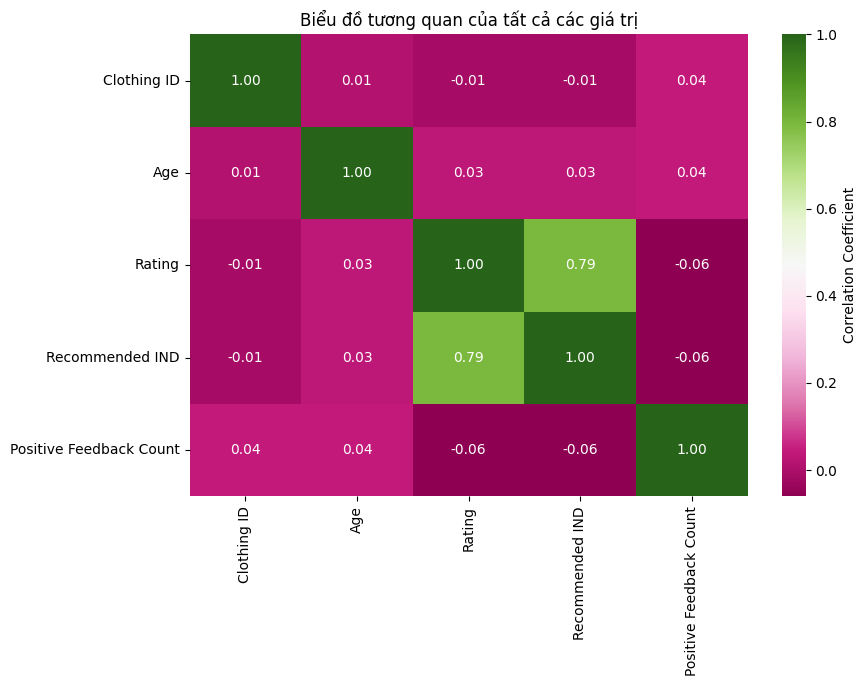

                         Clothing ID       Age    Rating  Recommended IND  \
Clothing ID                 1.000000  0.012012 -0.013512        -0.013418   
Age                         0.012012  1.000000  0.034557         0.034626   
Rating                     -0.013512  0.034557  1.000000         0.792920   
Recommended IND            -0.013418  0.034626  0.792920         1.000000   
Positive Feedback Count     0.041707  0.041396 -0.057749        -0.060361   

                         Positive Feedback Count  
Clothing ID                             0.041707  
Age                                     0.041396  
Rating                                 -0.057749  
Recommended IND                        -0.060361  
Positive Feedback Count                 1.000000  


In [ ]:
def plot_correlation(data):
  df = data.copy()
  columns_to_drop = ['Title', 'Title_lemmatized', 'Review Text', 'Review Text_lemmatized',
                     'Sentiment', 'Class Name', 'Division Name', 'Department Name', "Polarity", "Neutral", "Negative", "Positive"]
  df = df.drop(columns=columns_to_drop)
  f, ax = plt.subplots(figsize=[9,6])
  ax = sns.heatmap(df.corr(), annot=True, cmap='PiYG', fmt=".2f",cbar_kws={'label': 'Correlation Coefficient'})
  ax.set_title("Biểu đồ tương quan của tất cả các giá trị")
  plt.show()
  print(df.corr())

plot_correlation(df)

# 2.Huấn luyện mô hình

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import joblib
import lightgbm as lgb
import xgboost as xgb

RANDOM_STATE = 42

TARGET = 'Recommended IND'

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

text_cols_to_remove = ['Review Text_lemmatized', 'Title_lemmatized', 'Review Text', 'Title']
existing_text_cols = [col for col in text_cols_to_remove if col in X.columns]
if existing_text_cols:
    print(f"Removing text columns for this test: {existing_text_cols}")
    X = X.drop(columns=existing_text_cols)

id_cols_to_remove = ['Clothing ID']
existing_id_cols = [col for col in id_cols_to_remove if col in X.columns]
if existing_id_cols:
    print(f"Removing ID columns: {existing_id_cols}")
    X = X.drop(columns=existing_id_cols)

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Final columns in X:', list(X.columns))
print('Numeric cols:', numeric_cols)
print('Categorical cols:', categorical_cols)
print('Data shape:', X.shape)


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'\nTrain shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')
print('Target distribution in train:')
print(y_train.value_counts())

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine transformers
transformers = []
if numeric_cols:
    transformers.append(('num', numeric_transformer, numeric_cols))
if categorical_cols:
    transformers.append(('cat', categorical_transformer, categorical_cols))

if not transformers:
    raise ValueError("No valid columns found for training!")

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

# Test preprocessing
print("\n" + "="*50)
print("Testing preprocessing...")
try:
    X_train_transformed = preprocessor.fit_transform(X_train)
    X_test_transformed = preprocessor.transform(X_test)
    print(f"Preprocessing successful!")
    print(f"Training data shape after preprocessing: {X_train_transformed.shape}")
    print(f"Test data shape after preprocessing: {X_test_transformed.shape}")
except Exception as e:
    print(f"Preprocessing failed: {str(e)}")
    raise e

# Hàm huấn luyện và đánh giá model
def train_and_evaluate(clf, clf_name):
    print(f'\n--- Training {clf_name} ---')
    pipe = Pipeline(steps=[('preproc', preprocessor), ('clf', clf)])

    try:
        pipe.fit(X_train, y_train)
        print(f"✓ {clf_name} training completed successfully")

        # Prediction
        y_pred = pipe.predict(X_test)

        # Get probabilities if available
        if hasattr(pipe.named_steps['clf'], 'predict_proba'):
            y_proba = pipe.predict_proba(X_test)[:, 1]
        else:
            y_proba = None

        # Calculate metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        roc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
        result = {
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1_score': f1,
            'roc_auc': roc
        }

        print(f"Accuracy: {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall: {rec:.4f}")
        print(f"F1-score: {f1:.4f}")
        print(f"ROC-AUC: {roc:.4f}")

        print(f'\nClassification Report:')
        print(classification_report(y_test, y_pred, zero_division=0))

        print(f'\nConfusion Matrix:')
        print(confusion_matrix(y_test, y_pred))

        # Save pipeline
        joblib.dump(pipe, f'{clf_name}_pipeline.joblib')
        print(f"Saved: {clf_name}_pipeline.joblib")

        # Cross validation
        try:
            cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
            print(f'CV ROC-AUC (5-fold): {np.round(cv_scores, 4)}')
            print(f'CV ROC-AUC mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
        except Exception as e:
            print(f'CV scoring failed: {e}')

    except Exception as e:
        print(f"Error during {clf_name} training/evaluation: {str(e)}")
        import traceback
        print("Full error traceback:")
        traceback.print_exc()
    return result

print("\n" + "="*50)

# 1) Decision Tree
dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=6)
dt_result = train_and_evaluate(dt_clf, 'decision_tree')

# 2) LightGBM
print("\n" + "="*50)
lgb_clf = lgb.LGBMClassifier(
    random_state=RANDOM_STATE,
    n_estimators=200,
    learning_rate=0.05,
    verbose=-1
)
lightgbm_result = train_and_evaluate(lgb_clf, 'lightgbm')

# 3) XGBoost
print("\n" + "="*50)
xgb_clf = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    n_estimators=200,
    learning_rate=0.05,
    eval_metric='logloss',
    verbosity=0
)
xgboost_rersult = train_and_evaluate(xgb_clf, 'xgboost')

Removing text columns for this test: ['Review Text_lemmatized', 'Title_lemmatized']
Removing ID columns: ['Clothing ID']
Final columns in X: ['Age', 'Rating', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']
Numeric cols: ['Age', 'Rating', 'Positive Feedback Count']
Categorical cols: ['Division Name', 'Department Name', 'Class Name']
Data shape: (19452, 6)

Train shape: (15561, 6)
Test shape: (3891, 6)
Target distribution in train:
Recommended IND
1    12786
0     2775
Name: count, dtype: int64

Testing preprocessing...
Preprocessing successful!
Training data shape after preprocessing: (15561, 32)
Test data shape after preprocessing: (3891, 32)


--- Training decision_tree ---
✓ decision_tree training completed successfully
Accuracy: 0.9378
Precision: 0.9907
Recall: 0.9331
F1-score: 0.9610
ROC-AUC: 0.9751

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.96      0.85       694
           1       0.9

/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1108: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  X = _LGBMValidateData(
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1108: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  X = _LGBMValidateData(


Accuracy: 0.9378
Precision: 0.9749
Recall: 0.9487
F1-score: 0.9616
ROC-AUC: 0.9790

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       694
           1       0.97      0.95      0.96      3197

    accuracy                           0.94      3891
   macro avg       0.88      0.92      0.90      3891
weighted avg       0.94      0.94      0.94      3891


Confusion Matrix:
[[ 616   78]
 [ 164 3033]]
Saved: lightgbm_pipeline.joblib
CV ROC-AUC (5-fold): [0.9716 0.9653 0.9745 0.9721 0.9736]
CV ROC-AUC mean: 0.9714 ± 0.0032


--- Training xgboost ---
✓ xgboost training completed successfully
Accuracy: 0.9381
Precision: 0.9799
Recall: 0.9440
F1-score: 0.9616
ROC-AUC: 0.9785

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       694
           1       0.98      0.94      0.96      3197

    accuracy                           0.94      3891
   

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import joblib

def create_metrics_table(models_data, save_csv=None):
    df = pd.DataFrame(models_data).T
    df = df.round(4)

    for col in df.columns:
        df[f'{col}_rank'] = df[col].rank(ascending=False)

    df = df.sort_values('accuracy', ascending=False)

    print("Model Performance Comparison Table:")
    print("=" * 80)
    print(df[['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']])

    if save_csv:
        df.to_csv(save_csv)
        print(f"\n Table saved to: {save_csv}")

    return df


models_data = {
  'Decision Tree': dt_result,
  'LightGBM': lightgbm_result,
  'XGBoost': xgboost_rersult
}

create_metrics_table(models_data, save_csv='model_metrics.csv')


Model Performance Comparison Table:
               accuracy  precision  recall  f1_score  roc_auc
XGBoost          0.9381     0.9799  0.9440    0.9616   0.9785
Decision Tree    0.9378     0.9907  0.9331    0.9610   0.9751
LightGBM         0.9378     0.9749  0.9487    0.9616   0.9790

 Table saved to: model_metrics.csv


,accuracy,precision,recall,f1_score,roc_auc,accuracy_rank,precision_rank,recall_rank,f1_score_rank,roc_auc_rank
XGBoost,0.9381,0.9799,0.9440,0.9616,0.9785,1.0,2.0,2.0,1.5,2.0
Decision Tree,0.9378,0.9907,0.9331,0.9610,0.9751,2.5,1.0,3.0,3.0,3.0
LightGBM,0.9378,0.9749,0.9487,0.9616,0.9790,2.5,3.0,1.0,1.5,1.0
